In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,confusion_matrix
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

# Data loading

In [2]:
train_df = pd.read_csv('train_new.csv')
test_df = pd.read_csv('test_new.csv')
val_df = pd.read_csv('val_new.csv')

# Data preparation

In [3]:
THRESHOLD = 60
results_calculation = {}

filters_ignore = [
    'object_type',
    'sensor_id',
    'object_id',
]

In [4]:
def preprocess_nan_values(dataFrame,filters):
    """Replace NaN in categorical columns with empty string and maintain proper dtypes"""
   # Convert back to categorical type
    dataFrame = dataFrame.copy()
        

    for col in dataFrame.columns:
        if col in filters:
            dataFrame[col] = dataFrame[col].fillna('Unknown').astype(str)
        if col not in filters:
            dataFrame[col] = dataFrame[col].astype(float)
    
    return dataFrame

def preprocess_category_values(dataFrame,filters):
   # Convert back to categorical type
    dataFrame = dataFrame.copy()
        

    for col in dataFrame.columns:
        if col in filters:
            dataFrame[col] = dataFrame[col].fillna('Unknown').astype('category')
        if col not in filters:
            dataFrame[col] = dataFrame[col].astype(float)
    
    return dataFrame

In [5]:
# Split inputs and targets
train_inputs = train_df.drop(columns=['pdr'])
train_targets = train_df['pdr']
test_inputs = test_df.copy()
test_inputs_copy = test_df.copy(deep=True)
train_inputs_copy= train_df.copy(deep=True)

# Select features
dropped_columns = ['object_id',
                   'sensor_id',
                   'occlusion_level'
                  ]
train_inputs.drop(columns=dropped_columns, inplace=True)
dropped_columns.append('pdr')
test_inputs.drop(columns=dropped_columns, inplace=True)

# Transform categorical features
categorical_features = ['object_type']
oe = OrdinalEncoder()
train_inputs[categorical_features] = oe.fit_transform(train_inputs[categorical_features])
test_inputs[categorical_features] = oe.transform(test_inputs[categorical_features])

# Missing value imputation
train_inputs.fillna(0, inplace=True)
test_inputs.fillna(0, inplace=True)

# Prediction using XGBoost

In [6]:
dropped_columns_xg = [
    'object_type',
    'sensor_id',
]
train_inputs_xg = preprocess_category_values(train_inputs_copy.copy(),filters_ignore)
train_targets_xg = train_inputs_xg['pdr']

test_inputs_xg = preprocess_category_values(test_inputs_copy.copy(),filters_ignore)
test_targets_xg = test_inputs_xg['pdr']

train_inputs_xg.drop(columns=dropped_columns_xg, inplace=True)
test_inputs_xg.drop(columns=dropped_columns_xg, inplace=True)

X_train_xg, X_test_xg, y_train_xg, y_test_xg = train_test_split(
        train_inputs_xg, train_targets_xg, test_size=0.2, random_state=42
    )
model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        enable_categorical=True
    )

model.fit(X_train_xg, y_train_xg)

y_pred_xg = model.predict(X_test_xg)

r2 = r2_score(y_test_xg, y_pred_xg)
rmse = np.sqrt(mean_squared_error(y_test_xg, y_pred_xg))
mae = mean_absolute_error(y_test_xg, y_pred_xg)



print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.3e}")
print(f"MAE: {mae:.4f}")

results_calculation['Xg_Boost'] = {'r2':r2, 'rmse': "{:.3e}".format(rmse), 'mae':"{:.3e}".format(mae)}


R²: 1.0000
RMSE: 1.624e-05
MAE: 0.0000


# Prediction algorithm using Random Forest

In [7]:
# Split training and validation tests

X_train, X_test, y_train, y_test = train_test_split(train_inputs, train_targets, test_size = 0.2, random_state = 0)

# Create algorithm
rf = RandomForestRegressor()

# Train
rf.fit(X_train, y_train)

# Validation
val_predictions = rf.predict(X_test)
# print(test_inputs.head(10))
# Test
test_predictions = rf.predict(test_inputs)

# Compute error metric

In [8]:
rmse_rf = mean_squared_error(y_test, val_predictions, squared=False)
print(f"Root Mean Squared Error = {rmse / 1e6:.3} Mbit/s")
r2_rf = r2_score(y_test, val_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test_xg, y_pred_xg))
mae_rf = mean_absolute_error(y_test_xg, y_pred_xg)
print(f"R²: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.3e}")
print(f"MAE: {mae_rf:.4f}")

results_calculation['RF'] = {'r2':r2_rf, 'rmse': "{:.3e}".format(rmse_rf), 'mae':"{:.3e}".format(mae_rf)}


Root Mean Squared Error = 1.62e-11 Mbit/s
R²: 1.0000
RMSE: 1.624e-05
MAE: 0.0000


# Save results

In [9]:
# Add index to results
predictions_df = pd.DataFrame({'id': test_df.object_id, 'target': test_predictions})
predictions_df.to_csv("BenchmarkSubmission.csv", index = False)
predictions_df.head()

,id,target
0,1266f0ee-ae13-476c-a513-1a688af620af,0.800743
1,912301db-42d3-4f25-b8d4-8c762021884f,0.800743
2,f82f2878-e502-43ce-ac0f-71d4dfde6c45,0.800743
3,2171d6a1-8b87-46c7-bf69-1f89ab2fa963,0.800743
4,e574e265-b073-4788-ac29-e8529c9c88b9,0.800743


# Cat Boost Algorithm Prediction

In [10]:
import json
def calculateConfusionMatrix(predictor,testing_targets):

    predictions_binary = (predictor >= THRESHOLD).astype(int)
    test_targets_binary = (testing_targets >= THRESHOLD).astype(int)

    
    # Compute confusion matrix
    cm = confusion_matrix(test_targets_binary, predictions_binary)
    print(f"cm: {cm}")
    TN, FP, FN, TP = cm.ravel()
    return TN, FP, FN, TP

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()



categorical_features = [
    'object_type',
    'sensor_id',
    'object_id',
]

train_inputs_cat = preprocess_nan_values(train_inputs_copy.copy(),categorical_features)
train_targets_cat = train_inputs_cat['throughput']

test_inputs_cat = preprocess_nan_values(test_inputs_copy.copy(),categorical_features)
test_targets_cat = test_inputs_cat['throughput']



dropped_columns = ['throughput']
train_inputs_cat.drop(columns=dropped_columns, inplace=True)
test_inputs_cat.drop(columns=dropped_columns, inplace=True)

cat_features_indices = [train_inputs_cat.columns.get_loc(col) for col in categorical_features]

from catboost import Pool

#POOLING
train_pool = Pool(
    data=train_inputs_cat,
    label=train_targets_cat,
    cat_features=categorical_features
)

test_pool = Pool(
    data=test_inputs_cat,
    label=test_targets_cat,
    cat_features=categorical_features
)

# Model for CatBoostAlgorithm 
model_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.09,
    depth=4,
    verbose=1000,
    cat_features=cat_features_indices,
    random_seed=42,
    early_stopping_rounds=10,
    l2_leaf_reg=10,
    loss_function='RMSE',
    allow_writing_files=False
)



model_cat.fit(train_pool,eval_set=test_pool)

pred_cat = model_cat.predict(test_inputs_cat)







0:	learn: 0.2442382	test: 0.2630882	best: 0.2630882 (0)	total: 59.4ms	remaining: 59.3s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.06527955719
bestIteration = 173

Shrink model to first 174 iterations.


In [12]:
r2_cat = r2_score(test_targets_cat, pred_cat)
rmse_cat = np.sqrt(mean_squared_error(test_targets_cat, pred_cat))
mae_cat = mean_absolute_error(test_targets_cat, pred_cat)



print(f"R²: {r2_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f"MAE: {mae_cat:.4f}")

results_calculation['CatBoost'] = {'r2':r2_cat, 'rmse':  "{:.3e}".format(rmse_cat), 'mae':"{:.3e}".format(mae_cat)}


R²: 0.8674
RMSE: 0.0653
MAE: 0.0650


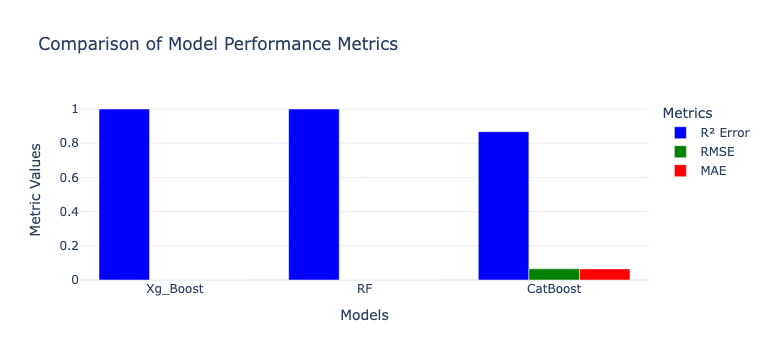

In [14]:
import plotly.graph_objects as go

model_names = list(results_calculation.keys())
r2_values = [results_calculation[model]['r2'] for model in model_names]
rmse_values = [results_calculation[model]['rmse'] for model in model_names]
mae_values = [results_calculation[model]['mae'] for model in model_names]

# Creating the bar chart
fig = go.Figure()

# Adding R-Square (R²) bars
fig.add_trace(go.Bar(
    x=model_names,
    y=r2_values,
    name='R² Error',
    marker_color='blue'
))

# Adding Root Mean Squared Error (RMSE) bars
fig.add_trace(go.Bar(
    x=model_names,
    y=rmse_values,
    name='RMSE',
    marker_color='green'
))

# Adding MAE bars
fig.add_trace(go.Bar(
    x=model_names,
    y=mae_values,
    name='MAE',
    marker_color='red'
))

# Updating layout
fig.update_layout(
    title='Comparison of Model Performance Metrics',
    xaxis_title='Models',
    yaxis_title='Metric Values',
    barmode='group',
    legend_title='Metrics',
    template='plotly_white'
)

# Show the plot
fig.show()